<a href="https://colab.research.google.com/github/yugan243/Deep-Learning-Pytorch/blob/main/3_Toy_MLP_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


In [ ]:
# get the data to the X and Y
coordinates, label = make_moons(n_samples=5000, random_state=0, noise=0.2)

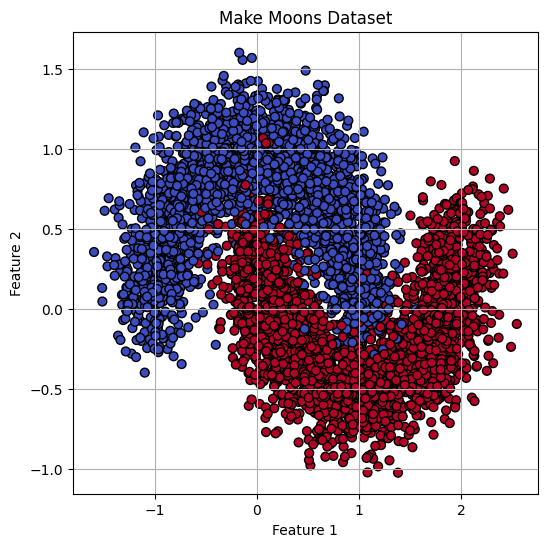

In [ ]:
# Visualize the data
plt.figure(figsize=(6,6))

plt.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    c=label,
    cmap='coolwarm',
    edgecolors='k',
    s=40
)

plt.title("Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
X = torch.from_numpy(coordinates)
Y = torch.from_numpy(label)
Y = Y.to(torch.float64)

# if torch.cuda.is_available():
#   device = torch.device('cuda')
#   X = X.to(device)
#   Y = Y.to(device)


In [ ]:
print(f"x: {X}")
print(f"X: {X.shape}")
print(f"Y: {Y}")
print(f"Y: {Y.shape}")


x: tensor([[ 0.8436,  0.7905],
        [ 1.0482, -0.6701],
        [ 1.6932,  0.3639],
        ...,
        [-0.4634,  0.7686],
        [ 0.1920,  0.2438],
        [-0.0833,  0.3587]], dtype=torch.float64)
X: torch.Size([5000, 2])
Y: tensor([0., 1., 1.,  ..., 0., 1., 1.], dtype=torch.float64)
Y: torch.Size([5000])


In [ ]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)

To do this the data should be on the cpu




In [ ]:
# Create datasets
train_dataset = TensorDataset(X_train, Y_train)
test_dataset = TensorDataset(X_test, Y_test)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)


**pin_memory** is a CUDA optimization. That makes the data transfer from cpu to gpu faster.

In [ ]:
class MoonDataClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(2, 16)
    self.relu1 = nn.ReLU()
    self.layer2 = nn.Linear(16, 8)
    self.relu2 = nn.ReLU()
    self.layer3 = nn.Linear(8,2)

  def forward(self, X):
    x = self.layer1(X)
    x = self.relu1(x)
    x = self.layer2(x)
    x = self.relu2(x)
    x = self.layer3(x)
    return x

In [ ]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(f"device: {device}")

device: cpu


In [ ]:
# initialize the model
model = MoonDataClassifier()
model = model.to(device=device)

In [ ]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

In [ ]:
# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
#Train the Neural Network

epochs = 500

for epoch in range(epochs):
  model.train()
  total_loss =0.0

  for X_batch, Y_batch in train_loader:
    X_batch = X_batch.to(device=device, dtype=torch.float32)
    Y_batch = Y_batch.to(device=device, dtype=torch.long)

    optimizer.zero_grad()

    logits = model(X_batch)

    loss = criterion(logits, Y_batch)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch + 1) % 50 == 0:
    average_loss = total_loss/len(train_loader)

    print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 50/500, Loss: 0.0801
Epoch 100/500, Loss: 0.0776
Epoch 150/500, Loss: 0.0753
Epoch 200/500, Loss: 0.0749
Epoch 250/500, Loss: 0.0742
Epoch 300/500, Loss: 0.0720
Epoch 350/500, Loss: 0.0733
Epoch 400/500, Loss: 0.0715
Epoch 450/500, Loss: 0.0719
Epoch 500/500, Loss: 0.0712


In [ ]:
def evaluate(model, test_loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, Y_batch in test_loader:

            X_batch = X_batch.to(device=device, dtype=torch.float32)
            Y_batch = Y_batch.to(device=device, dtype=torch.long)

            outputs = model(X_batch)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == Y_batch).sum().item()
            total += Y_batch.size(0)

    accuracy = correct / total

    return accuracy

In [ ]:
test_accuracy = evaluate(model, test_loader, device)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 96.80%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_decision_boundary(model, X, Y, device, step=0.02):
    model.eval()

    # Convert the real dataset to CPU NumPy arrays for plotting
    X_cpu = X.detach().cpu().numpy()
    Y_cpu = Y.detach().cpu().numpy()

    # Find the plotting area and add a small margin
    x1_min = X_cpu[:, 0].min() - 0.5
    x1_max = X_cpu[:, 0].max() + 0.5

    x2_min = X_cpu[:, 1].min() - 0.5
    x2_max = X_cpu[:, 1].max() + 0.5

    # Create a grid covering the entire feature space
    xx, yy = np.meshgrid(
        np.arange(x1_min, x1_max, step),
        np.arange(x2_min, x2_max, step)
    )

    # Convert grid coordinates into model inputs:
    # [[x1, x2], [x1, x2], ...]
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    grid_tensor = torch.tensor(
        grid_points,
        dtype=torch.float32,
        device=device
    )

    # Predict the class of every grid point
    with torch.no_grad():
        outputs = model(grid_tensor)
        grid_predictions = outputs.argmax(dim=1)

    # Move predictions back to CPU and restore grid shape
    Z = grid_predictions.cpu().numpy()
    Z = Z.reshape(xx.shape)

    # Plot predicted regions
    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot the actual data points
    plt.scatter(
        X_cpu[:, 0],
        X_cpu[:, 1],
        c=Y_cpu,
        edgecolors="black",
        s=25
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Neural Network Decision Boundary")
    plt.show()

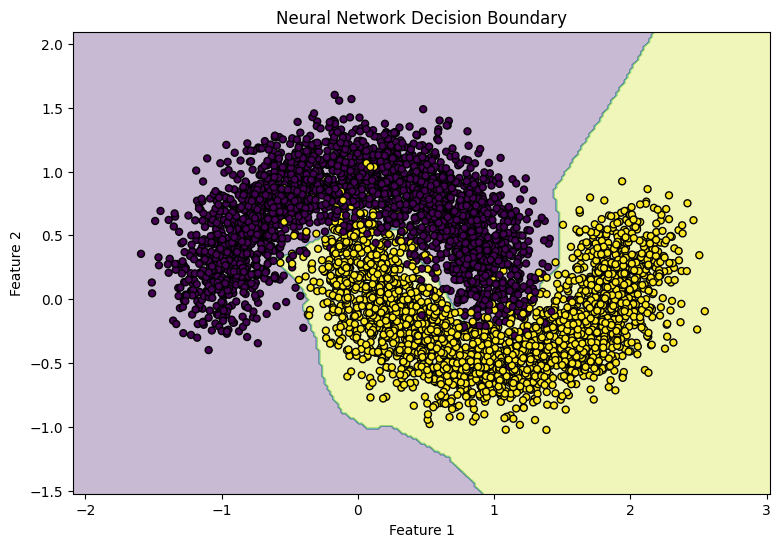

In [ ]:
plot_decision_boundary(
    model=model,
    X=X,
    Y=Y,
    device=device
)